In [48]:
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import wiener
import pywt


In [49]:
class CHIMEFRBDataset(Dataset):
    def __init__(self, hdf5_path, catalog_path, target_length):
        self.hdf5_path = hdf5_path
        self.dt = 0.009830400085775182 * 1000
        self._h5 = None

        self.target_length = target_length
        cat = pd.read_csv(catalog_path, low_memory=False)
        cat["repeater_name"] = cat["repeater_name"].fillna("").str.strip()
        self.repeater_set = set(
            cat.loc[cat["repeater_name"] != "", "tns_name"].str.strip()
        )
        with h5py.File(hdf5_path, "r") as f:
            self.keys = list(f.keys())
        self.labels = np.array([int(k in self.repeater_set) for k in self.keys], dtype=np.int64)

    @staticmethod
    def _pad_or_crop(wfall, target_length, center_idx):
        n_freq, n_time = wfall.shape
        half = target_length // 2
        start = center_idx - half
        end = start + target_length

        if start >= 0 and end <= n_time:
            return wfall[:, start:end]

        src_start = max(start, 0)
        src_end = min(end, n_time)
        out = np.zeros((n_freq, target_length), dtype=wfall.dtype)
        dst_start = src_start - start
        out[:, dst_start:dst_start + (src_end - src_start)] = wfall[:, src_start:src_end]
        return out

    def _get_file(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.hdf5_path, "r")
        return self._h5

    def __len__(self):
        return len(self.keys)
    
    def __gaussian_filter__(self, wfall, sigma):
        return gaussian_filter(wfall, sigma=sigma, radius=2)

    def __getitem__(self, idx):
        key = self.keys[idx]

        f = self._get_file()
        wfall = f[key]["wfall_plot"][:]
        extent = np.array(f[key]["extent"])
        wfall = self.__gaussian_filter__(wfall, sigma=1)

        wfall = wfall.astype(np.float32)
        std = wfall.std(axis=1, keepdims=True)
        std[std == 0] = 1.0  # avoid divide-by-zero for masked channels
        wfall = (wfall - wfall.mean(axis=1, keepdims=True)) / std

        peak = round(-extent[0] / self.dt)
        wfall = self._pad_or_crop(wfall, self.target_length, peak)
        tensor = torch.from_numpy(wfall)
        label = torch.tensor(int(key in self.repeater_set), dtype=torch.long)

        return tensor, label

Dataset: 4536 | repeaters: 981 (21.6%)


/Users/rohanarni/Projects/chime-catalog-two-analysis/.chime-analysis/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


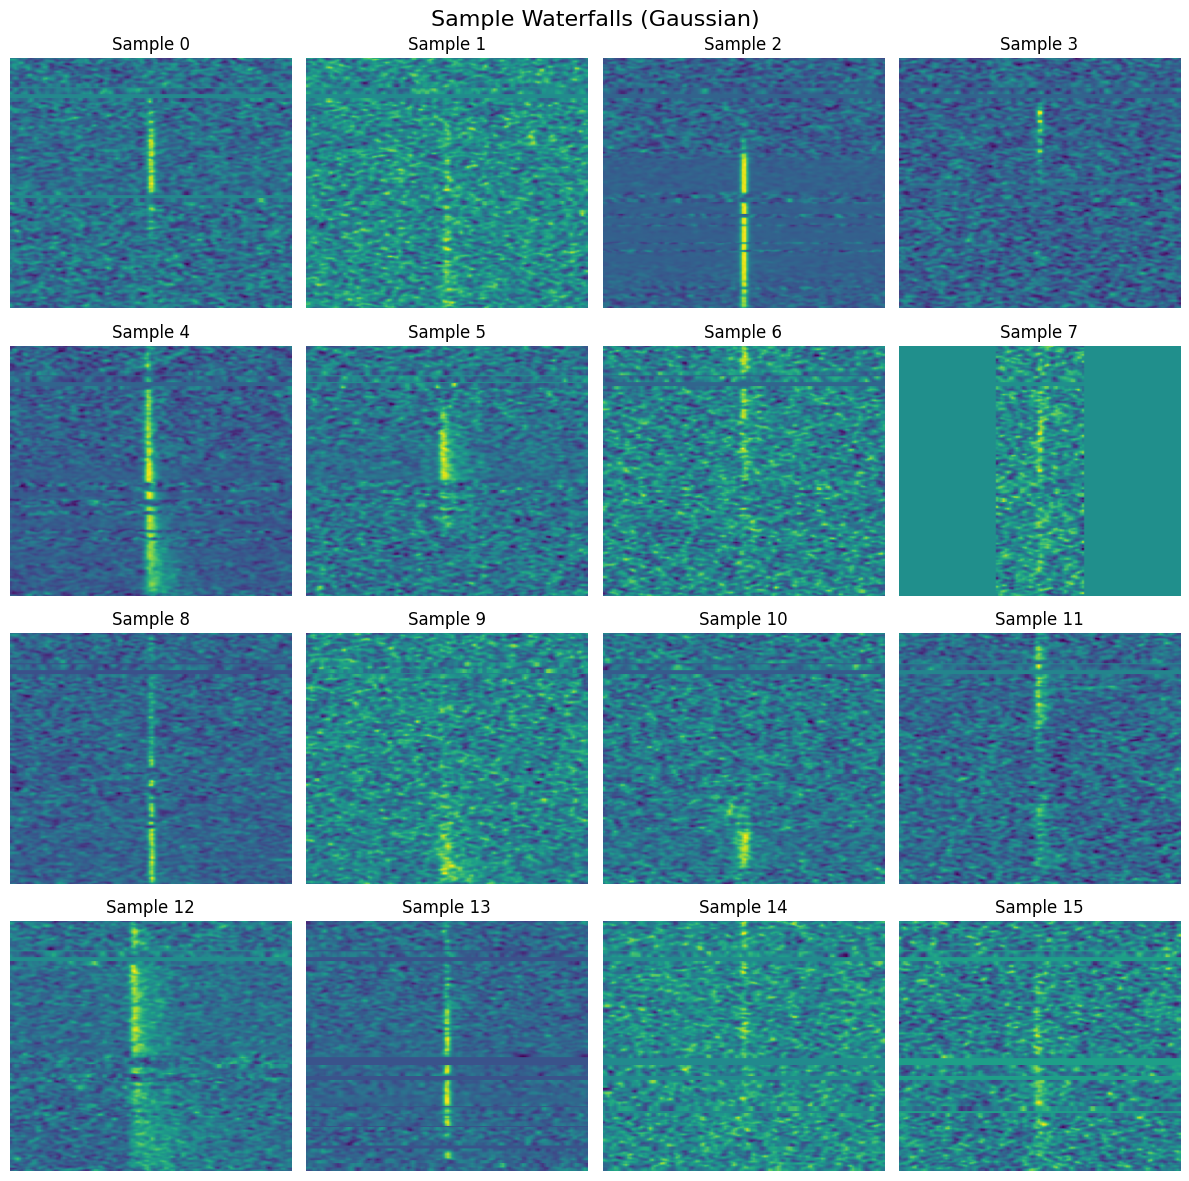

In [50]:
TARGET_LENGTH = 128
BATCH_SIZE = 64
NUM_WORKERS = 0
FOLD_IDX = 3 
 
HDF5_PATH = "all_bursts.hdf5"
CATALOG_PATH = "chimefrbcat2.csv"

dataset = CHIMEFRBDataset(HDF5_PATH, CATALOG_PATH, TARGET_LENGTH)
n_total = len(dataset)
n_rep = int(dataset.labels.sum())
print(f"Dataset: {n_total} | repeaters: {n_rep} ({100 * n_rep / n_total:.1f}%)")

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# load one batch

sample = next(iter(loader))[0]

# plot the first 16 samples in the batch
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("Sample Waterfalls (Gaussian)", fontsize=16)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample[i].numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(f'Sample {i}')
    ax.axis('off')
plt.tight_layout()